In [2]:
import numpy as np

# Loading data from the 'mnist_compressed.npz' file

data = np.load('mnist_compressed.npz')

In [3]:
print(data.files)

['train_images', 'train_labels', 'test_images', 'test_labels']


In [4]:
data["train_images"][0].shape

(28, 56)

In [58]:
import torch
from torch.utils.data import Dataset, DataLoader
class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype = torch.long)
        self.images = self.images.unsqueeze(1)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

    def __len__(self):
        return len(self.images)

train_dataset = MNISTDataset(data["train_images"], data["train_labels"])
test_dataset = MNISTDataset(data["test_images"], data["test_labels"])
        

In [59]:
print(train_dataset.images.shape)
print(train_dataset.labels.shape)
print(test_dataset.images.shape)
print(test_dataset.labels.shape)

torch.Size([60000, 1, 28, 56])
torch.Size([60000])
torch.Size([10000, 1, 28, 56])
torch.Size([10000])


In [60]:
train_dataset[0][0]

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [61]:
len(train_dataset)

60000

In [62]:
print(train_dataset.labels.min())
print(train_dataset.labels.max())

tensor(0)
tensor(99)


In [63]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [64]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 1, 28, 56])
torch.Size([32])


In [65]:
len(train_loader)


1875

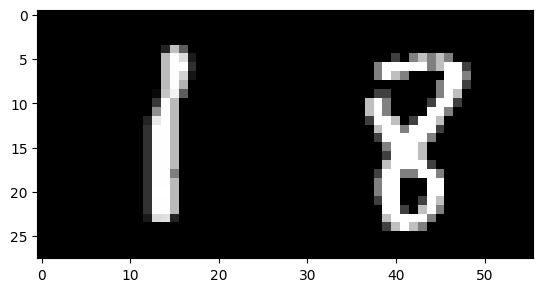

In [66]:
import matplotlib.pyplot as plt

plt.imshow(train_dataset[1][0][0], cmap="gray")
plt.show()

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        
        self.pool = nn.MaxPool2d(2,2)
        
        self.fc1 = nn.Linear(64*5*12, 128)
        self.fc2 = nn.Linear(128, 100)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) 
        x = self.pool(F.relu(self.conv2(x)))
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [110]:
model = MNIST_CNN()

In [111]:
activations = {}

def hook_fn1(module, input, output):
    activations["conv1"] = output

def hook_fn2(module, input, output):
    activations["conv2"] = output
    
hook1 = model.conv1.register_backward_hook(hook_fn1)
hook2 = model.conv2.register_backward_hook(hook_fn2)

In [112]:
CELoss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [113]:
for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader:
        outputs= model(images)
        loss = CELoss(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

c:\Users\aadit\Desktop\AI_Engineer_Revision\.venv\Lib\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss: 0.7029585450942317
Epoch 2, Loss: 0.16794235759948692
Epoch 3, Loss: 0.12372554814554751
Epoch 4, Loss: 0.094723759635631
Epoch 5, Loss: 0.08070334177766926


In [114]:
correct = 0
total = 0

# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

with torch.no_grad():
    for images, labels in train_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
        
print("Accuracy:", 100*correct/total)
        
    

Accuracy: 98.27


In [115]:
correct = 0
total = 0

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
        
print("Accuracy:", 100*correct/total)
        
    

Accuracy: 95.61


In [116]:
images, _ = next(iter(train_loader))
_ = model(images)
feature_maps1 = activations["conv1"][0]
feature_maps2 = activations["conv2"][0]

c:\Users\aadit\Desktop\AI_Engineer_Revision\.venv\Lib\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [118]:
print(activations["conv1"][0].shape)
print(activations["conv2"][0].shape)

torch.Size([32, 32, 26, 54])
torch.Size([32, 64, 11, 25])


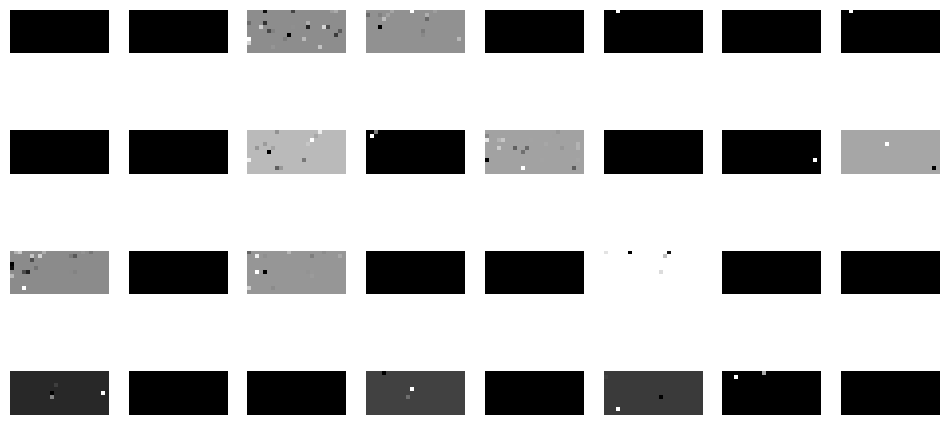

In [121]:
import matplotlib.pyplot as plt

# Take first image in batch
feature_maps_out1 = feature_maps1[0]# shape: (32, H, W)
feature_maps_out2 = feature_maps2[0]
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps_out2[i].detach().numpy(), cmap='gray')
    ax.axis('off')

plt.show()

In [100]:
activations["conv1"]

(tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
